<a href="https://colab.research.google.com/github/Gkcoli/CCDATSCL_ASSIGNMENT_COM222-ML/blob/main/Exercise4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4

This exercise focuses on data visualization and interpretation using a real-world COVID-19 dataset. The dataset contains daily records of confirmed cases, deaths, recoveries, and active cases across countries and regions, along with temporal and geographic information.
The goal of this exercise is not only to create charts, but to choose appropriate visualizations, apply correct data aggregation, and draw meaningful insights from the data. You will work with time-based, categorical, numerical, and geographic variables, and you are expected to think critically about how design choices affect interpretation.

Your visualizations should follow good practices:
- Use clear titles, axis labels, and legends
- Choose chart types appropriate to the data and question
- Avoid misleading scales or cluttered designs
- Clearly explain patterns, trends, or anomalies you observe

Unless stated otherwise, you may filter, aggregate, or group the data as needed.

<img src="https://d3i6fh83elv35t.cloudfront.net/static/2020/03/Screen-Shot-2020-03-05-at-6.29.29-PM-1024x574.png"/>

In [1]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'corona-virus-report' dataset.
Path to dataset files: /kaggle/input/corona-virus-report


In [2]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


In [3]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [5]:
pd.set_option('display.float_format', lambda x: '%2f' % x)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [4]:
df.query("`Country/Region` == 'Philippines'")

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
180,NaN,Philippines,12.879721,121.774017,2020-01-22,0,0,0,0,Western Pacific
441,NaN,Philippines,12.879721,121.774017,2020-01-23,0,0,0,0,Western Pacific
702,NaN,Philippines,12.879721,121.774017,2020-01-24,0,0,0,0,Western Pacific
963,NaN,Philippines,12.879721,121.774017,2020-01-25,0,0,0,0,Western Pacific
1224,NaN,Philippines,12.879721,121.774017,2020-01-26,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
47943,NaN,Philippines,12.879721,121.774017,2020-07-23,74390,1871,24383,48136,Western Pacific
48204,NaN,Philippines,12.879721,121.774017,2020-07-24,76444,1879,24502,50063,Western Pacific
48465,NaN,Philippines,12.879721,121.774017,2020-07-25,78412,1897,25752,50763,Western Pacific
48726,NaN,Philippines,12.879721,121.774017,2020-07-26,80448,1932,26110,52406,Western Pacific


In [16]:
df.nunique()


,0
Province/State,78
Country/Region,187
Lat,260
Long,261
Date,188
Confirmed,10861
Deaths,3640
Recovered,7609
Active,8641
WHO Region,6


In [17]:
df.describe()


,Lat,Long,Date,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,49068,49068.000000,49068.000000,49068.000000,49068.000000
mean,21.433730,23.528236,2020-04-24 12:00:00,16884.904255,884.179160,7915.713479,8085.011617
min,-51.796300,-135.000000,2020-01-22 00:00:00,0.000000,0.000000,0.000000,-14.000000
25%,7.873054,-15.310100,2020-03-08 18:00:00,4.000000,0.000000,0.000000,0.000000
50%,23.634500,21.745300,2020-04-24 12:00:00,168.000000,2.000000,29.000000,26.000000
75%,41.204380,80.771797,2020-06-10 06:00:00,1518.250000,30.000000,666.000000,606.000000
max,71.706900,178.065000,2020-07-27 00:00:00,4290259.000000,148011.000000,1846641.000000,2816444.000000
std,24.950320,70.442740,NaN,127300.205272,6313.584411,54800.918731,76258.903026


## A. Time-Based Visualizations

1. Global Trend `(5 pts)`

Aggregate the data by Date and create a line chart showing the global number of confirmed COVID-19 cases over time.

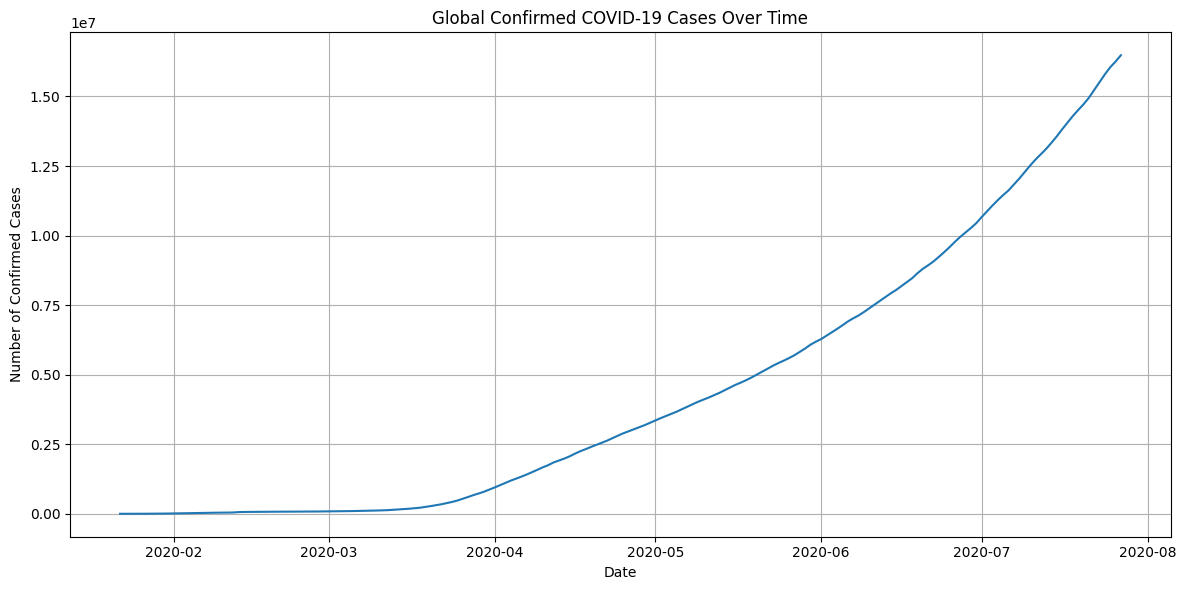

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate data by Date and sum 'Confirmed' cases
global_cases = df.groupby('Date')['Confirmed'].sum().reset_index()

# Create the line chart
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Confirmed', data=global_cases)
plt.title('Global Confirmed COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Confirmed Cases')
plt.grid(True)
plt.tight_layout()
plt.show()

2. Country-Level Trends `(5 pts)`

Select three countries and visualize their confirmed case counts over time on the same plot.

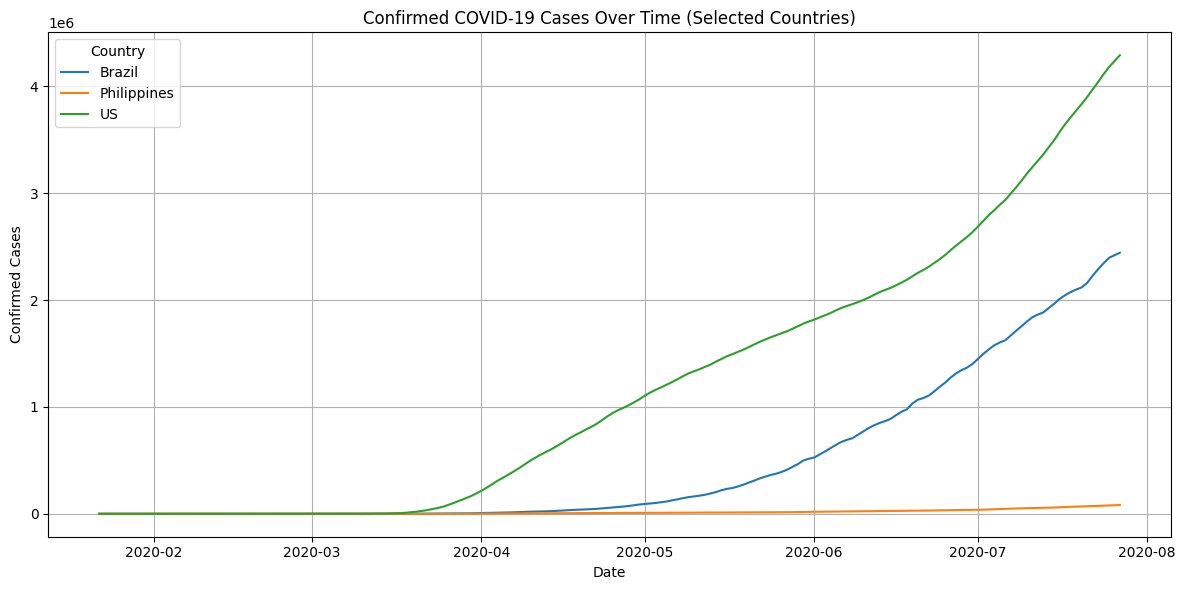

In [20]:
# put your answer here

# Select countries
countries = ['US', 'Brazil', 'Philippines']

country_df = df[df['Country/Region'].isin(countries)]

# Aggregate by Date and Country
country_trends = (
    country_df
    .groupby(['Date', 'Country/Region'])['Confirmed']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=country_trends,
    x='Date',
    y='Confirmed',
    hue='Country/Region'
)
plt.title('Confirmed COVID-19 Cases Over Time (Selected Countries)')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()


3. Active vs Recovered `(5 pts)`

For a selected country, create a line chart showing Active and Recovered cases over time.

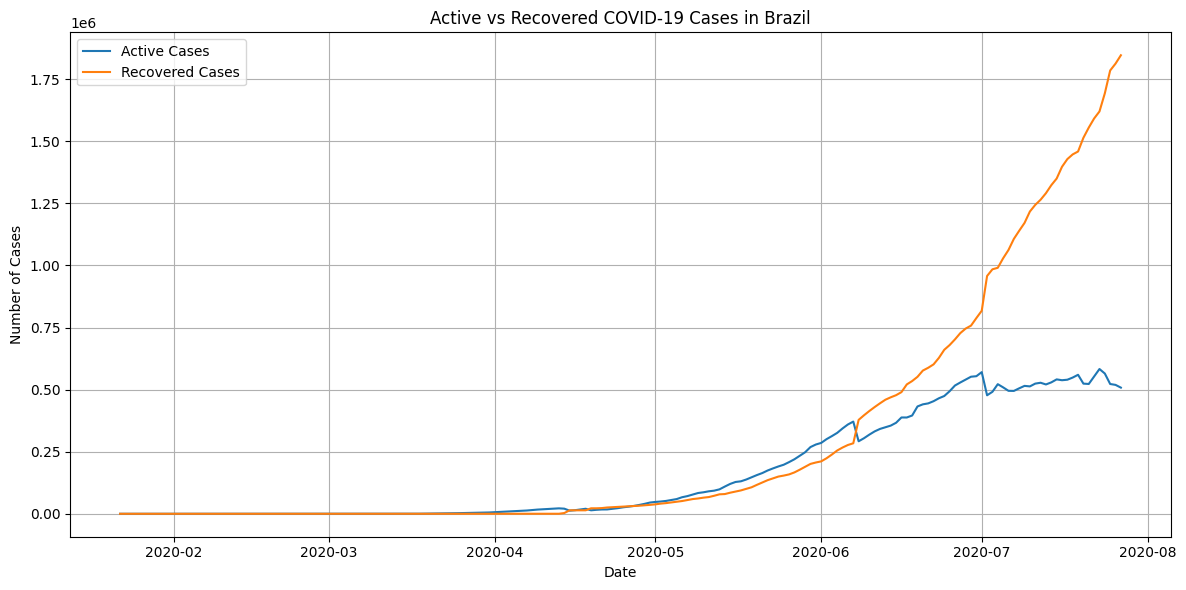

In [21]:
# put your answer here
country = 'Brazil'

country_data = (
    df[df['Country/Region'] == country]
    .groupby('Date')[['Active', 'Recovered']]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(country_data['Date'], country_data['Active'], label='Active Cases')
plt.plot(country_data['Date'], country_data['Recovered'], label='Recovered Cases')
plt.title(f'Active vs Recovered COVID-19 Cases in {country}')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## B: Comparative Visualizations

4. Country Comparison `(5 pts)`

Using data from a single date, create a bar chart showing the top 10 countries by confirmed cases.

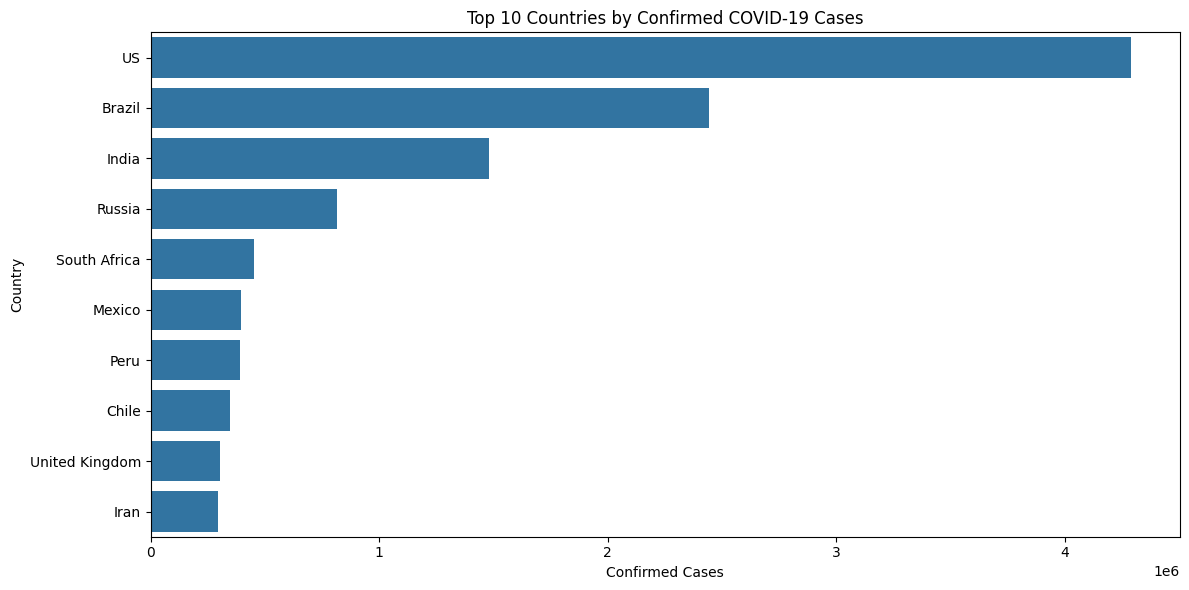

In [32]:
# put your answer here
# Use the most recent date
latest_date = df['Date'].max()

latest_data = df[df['Date'] == latest_date]

top10 = (
    latest_data
    .groupby('Country/Region')['Confirmed']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='Confirmed', y='Country/Region')
plt.title('Top 10 Countries by Confirmed COVID-19 Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


5. WHO Region Comparison `(5 pts)`

Aggregate confirmed cases by WHO Region and visualize the result using a bar chart.

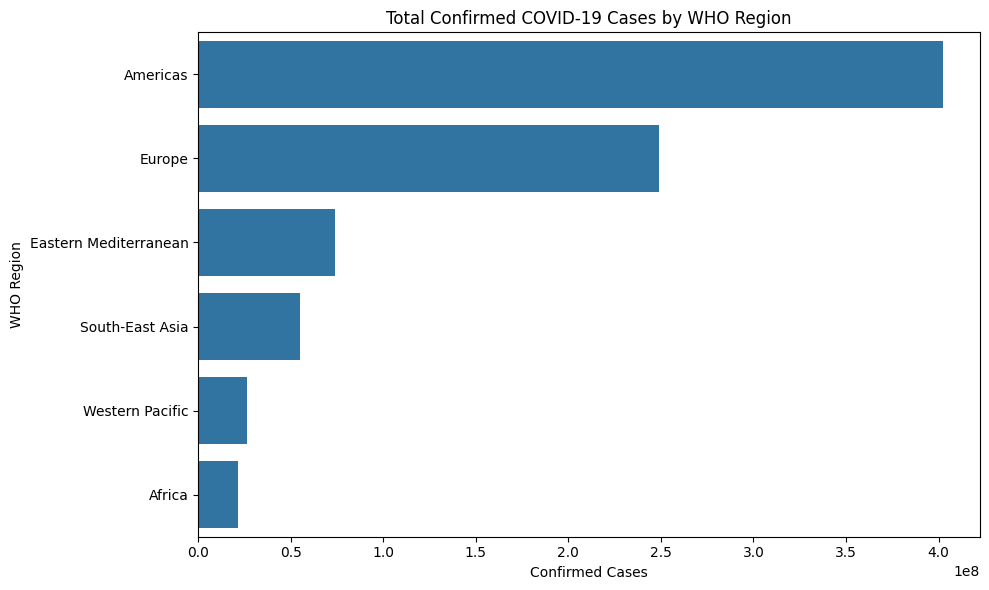

In [23]:
# put your answer here
region_cases = (
    df.groupby('WHO Region')['Confirmed']
    .sum()
    .reset_index()
    .sort_values(by='Confirmed', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=region_cases, x='Confirmed', y='WHO Region')
plt.title('Total Confirmed COVID-19 Cases by WHO Region')
plt.xlabel('Confirmed Cases')
plt.ylabel('WHO Region')
plt.tight_layout()
plt.show()


## C. Geographic Visualization

6. Geographic Spread `(10 pts)`

Using Latitude and Longitude, create a map-based visualization showing confirmed cases for a selected date.

In [49]:
import plotly.express as px
df_date = df[df['Date'] == "2020-05-11"]

fig = px.choropleth(
    df_date,
    locations = 'Country/Region',
    locationmode = 'country names',
    color = 'Confirmed',
    hover_name='Country/Region',
    projection='natural earth',
    title='Global Geographic Distribution of Confirmed COVID-19 Cases on 2020-05-11'
)

fig.show()


7. Regional Clustering `(15 pts)`

Create a visualization that shows how confirmed cases are distributed geographically within a single WHO Region.

In [63]:
df['Confirmed Cases per Region'] = df.groupby('WHO Region')['Confirmed'].transform('sum')
who_confirmed = df[['WHO Region', 'Country/Region', 'Confirmed Cases per Region']]
who_confirmed

,WHO Region,Country/Region,Confirmed Cases per Region
0,Eastern Mediterranean,Afghanistan,74082892
1,Europe,Albania,248879793
2,Africa,Algeria,21791827
3,Europe,Andorra,248879793
4,Africa,Angola,21791827
...,...,...,...
49063,Africa,Sao Tome and Principe,21791827
49064,Eastern Mediterranean,Yemen,74082892
49065,Africa,Comoros,21791827
49066,Europe,Tajikistan,248879793


In [64]:
fig = px.choropleth(
    who_confirmed,
    locations='Country/Region',
    locationmode='country names',
    color='Confirmed Cases per Region',
    hover_name='Country/Region',
    hover_data={'Confirmed Cases per Region': True},
    color_continuous_scale=px.colors.sequential.Plasma,
    title=f'Confirmed Cases per WHO Region'
)

# Note: mapbox_style is not applicable to px.choropleth, only px.choropleth_mapbox
fig.update_layout(margin={'r':0, 't':40, 'l':0, 'b':0})
fig.show()